Bing Chen

ST 554 Project 3

4/19/2026

# Introduction

For this project, we want to fit a machine learning model, read in a stream of data created ourselves, and use the model to do predictions on the stream and write those out to the console. 

First, let's read in the data we want to fit the model on. This data contains information about power
consumption from different zones of Tetouan city and various variables like time of day, temperature, and
humidity. We'll read in using `pandas`, then convert into a Spark dataframe. 

## Read in data 

In [1]:
import pandas as pd 

power = pd.read_csv("https://www4.stat.ncsu.edu/~online/datasets/power_ml_data.csv")

power.head()

,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Power_Zone_1,Power_Zone_2,Power_Zone_3,Month,Hour
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,1,0
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,1,0
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,1,0
3,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,1,0
4,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,1,0


Now let's convert it into a Spark dataframe. We need to create a spark session and then convert. 

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master('local[*]').appName('my_app').getOrCreate()

spower = spark.createDataFrame(power)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/18 20:33:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Now we have the data ready, we want to make prediction on `Power_Zone_3`, and we'll use all other variables as the predictor. We want to fit an elastic net model using CV. Before we fit the model, let's consider some transformations. 

Ler's check if the `Hour` column is stored as double, if not we want to use `SQLTransformer` to cast the variable as a double Then, we'll `Binarize` the Hour column based on the column being less than 6.5 or not to separate days and nights. We'll consider `One-hot encode` the Month column, run a PCA fit on the `Temperature`, `Humidity`, `Wind_Speed`, `General_Diffuse_Flows`, and `Diffuse_Flows columns`. To do this, we'll first used `VectorAssembler` to place these variables in a column then use `PCA`. When we are ready, we’ll use two fitted PCA features, the binary `Hour`, `Power_Zone_1`, `Power_Zone_2`, and the `Month` indicator variables. 


In [3]:
spower.dtypes

[('Temperature', 'double'),
 ('Humidity', 'double'),
 ('Wind_Speed', 'double'),
 ('General_Diffuse_Flows', 'double'),
 ('Diffuse_Flows', 'double'),
 ('Power_Zone_1', 'double'),
 ('Power_Zone_2', 'double'),
 ('Power_Zone_3', 'double'),
 ('Month', 'bigint'),
 ('Hour', 'bigint')]

## Create Transformers

In [4]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import SQLTransformer, Binarizer, StringIndexer, OneHotEncoder, VectorAssembler, PCA

In [5]:
# cast to DoubleType
sqlTrans = SQLTransformer(
    statement="""
    SELECT
        *,
        CAST(Hour AS DOUBLE) AS Hour_dbl,
        `Power_Zone_3` AS label
    FROM __THIS__
    """
)

#Binarize Hour 
binaryTrans = Binarizer(
    threshold=6.5,
    inputCol="Hour_dbl",
    outputCol="Hour_indicator"
)

# create indexer for Month 
month_indexer = StringIndexer(
    inputCol="Month", 
    outputCol="Month_idx", 
    handleInvalid="keep")


# One hot encode Month
month_ohe = OneHotEncoder(
    inputCols=["Month_idx"],
    outputCols=["Month_ohe"],
    dropLast=True
)

#assumble the columns into one column for PCA
pca_input_assembler = VectorAssembler(
    inputCols=[
        "Temperature",
        "Humidity",
        "Wind_Speed",
        "General_Diffuse_Flows",
        "Diffuse_Flows"
    ],
    outputCol="pca_input",
    handleInvalid="keep"
)

# perform PCA
pca = PCA(
    k=2,
    inputCol="pca_input",
    outputCol="pca_features"
)

# assemble feature columns 
feature_assembler = VectorAssembler(
    inputCols=[
        "pca_features",
        "Hour_indicator",
        "Power_Zone_1",
        "Power_Zone_2",
        "Month_ohe"
    ],
    outputCol="features",
    handleInvalid="keep"
)



## Set up and Carry out CV 

After we define the transformations, we want to fit a Linear regression using CV. We want to build a grid for all combinations of 0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1 on `regParam` and `elasticNetParam`. 

In [6]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(featuresCol="features", labelCol="label")
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .addGrid(lr.elasticNetParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .build()

Now set up the `Pipeline`. 

In [7]:
#create pipeline 
pipeline = Pipeline(stages=[
    sqlTrans,
    binaryTrans,
    month_indexer,
    month_ohe,
    pca_input_assembler,
    pca,
    feature_assembler, 
    lr
])

Now, we can use the `CrossValidator()` function to run k-fold CV over the grid of tuning parameters we just set up. We'll use the default RMSE metric to evaluate our model. 


In [8]:
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse"),
    numFolds=5
)

In [9]:
cvModel = crossval.fit(spower)

26/04/18 20:33:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/18 20:33:42 WARN Instrumentation: [042c1d78] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:45 WARN Instrumentation: [9c327d25] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:46 WARN Instrumentation: [9dd602e4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:48 WARN Instrumentation: [32b4af98] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:49 WARN Instrumentation: [7ad717f8] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:50 WARN Instrumentation: [506a26a2] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 20:33:51 WARN Instrumentation: [36dd8e82] regP

In [12]:
bestModel = cvModel.bestModel
bestLR = bestModel.stages[-1]

print("Best regParam:", bestLR.getRegParam())
print("Best elasticNetParam:", bestLR.getElasticNetParam())
print("Best CV RMSE:", min(cvModel.avgMetrics))

Best regParam: 0.99
Best elasticNetParam: 0.25
Best CV RMSE: 2147.815838553853


Looks like optimal regularization parameter is regParam = 0.95, which is very large. This indicates that strong regularization is needed. The best elastic net parameter is 0.75, that penalty is mostly L1 with some L2. The lowest CV RMSE is 2147.63! Now we ready to report the training set RMSE by using our best model chosen by CV as a transformer. 

In [14]:
pred_df = cvModel.bestModel.transform(spower)
evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

train_rmse = evaluator.evaluate(pred_df)

print(train_rmse)

2147.098808265091


The training RMSE is 2147.10, which is extremely close to the cross-validated RMSE of 2147.63. This suggsts that the model is not overfitting, since its performance is nearly the same as its estimated performance.

## Residuals 

After we have the predictions, we can compute the residuls, which is $$Y_i - \hat Y_i $$.

In [15]:
from pyspark.sql.functions import col

res_df = pred_df.withColumn(
    "residual",
    col("label") - col("prediction")
)

res_df.select("label", "prediction", "residual").show(20, truncate=False)

+-----------+------------------+------------------+
|label      |prediction        |residual          |
+-----------+------------------+------------------+
|20240.96386|20873.47274724175 |-632.5088872417509|
|20131.08434|18657.09208498755 |1473.9922550124502|
|19668.43373|18201.82285255912 |1466.6108774408822|
|18899.27711|17587.96015477226 |1311.3169552277395|
|18442.40964|16994.879861941565|1447.529778058437 |
|18130.12048|16515.464675875788|1614.6558041242133|
|17945.06024|16091.196440140582|1853.8637998594168|
|17459.27711|15720.80526784006 |1738.4718421599391|
|17025.54217|15269.34084579076 |1756.2013242092398|
|16794.21687|14936.791521591764|1857.4253484082365|
|16638.07229|14650.888882774292|1987.183407225708 |
|16395.18072|14413.505585050876|1981.6751349491242|
|16117.59036|14081.699735198385|2035.8906248016156|
|15822.6506 |13623.877591812914|2198.773008187087 |
|15672.28916|13449.37902698798 |2222.910133012021 |
|15597.10843|13301.303118678414|2295.8053113215865|
|15510.36145

We can plot the residuls to get a better understanding. First convert to `pandas` dataframe, then use `matplot`. 

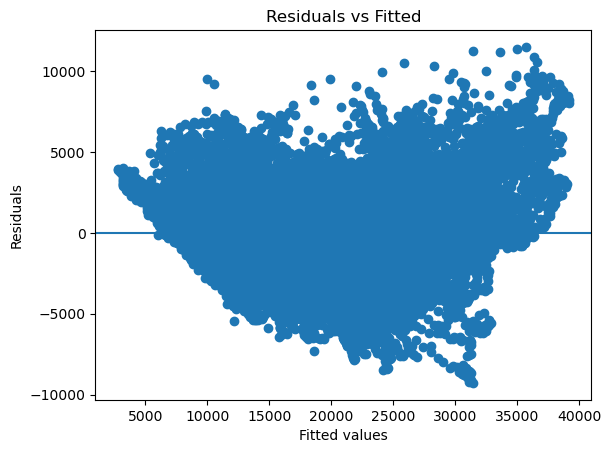

In [16]:
pdf = res_df.select("prediction", "residual").toPandas()

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(pdf["prediction"], pdf["residual"])
plt.axhline(0)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

The Residuals vs. Fitted values plot shows a clear curvature trend, which may suggest that the linearity assumption is validated. We can consider adding a quadratic term. But for now, let's keep it as is and proceed to the next step. 

# Stream Data

## Set up Schema

Import the necessary functions. Folder csv_files was created to send files to, now set up to listen to new data. 

In [17]:
from pyspark.sql.types import StructType
from pyspark.sql.functions import col
from pyspark.sql.types import *

# Set up the schema
myschema = (StructType()
    .add("Temperature", DoubleType(), True)
    .add("Humidity", DoubleType(), True)
    .add("Wind_Speed", DoubleType(), True)
    .add("General_Diffuse_Flows", DoubleType(), True)
    .add("Diffuse_Flows", DoubleType(), True)
    .add("Power_Zone_1", DoubleType(), True)
    .add("Power_Zone_2", DoubleType(), True)
    .add("Power_Zone_3", DoubleType(), True)
    .add("Month", IntegerType(), True)
    .add("Hour", IntegerType(), True)
)


## Read in Stream 
Now we are ready to set up to read stream

In [25]:

# set up to read stream 
power = (
    spark.readStream
    .schema(myschema)
    .option("header", True)
    .csv("csv_files")
)



## Transform/Aggregation step 
First, we want to use the fitted model to generate predictions, then get residuals. We'll return only label, prediction, residuals. 

In [26]:


pred_stream = cvModel.bestModel.transform(power)

pred_stream = pred_stream.withColumn(
    "residual",
    col("label") - col("prediction")
).select("label", "prediction", "residual")


Secondly, we rename the response column to label 

In [27]:

# rename response column to label
label_stream = SQLTransformer(statement="""
    SELECT *,
           CAST(Power_Zone_3 AS DOUBLE) AS label
    FROM __THIS__
""").transform(power)



Then, we want to join the two steps on label! 

In [28]:

# join the two transformed streams on label
joined_stream = pred_stream.join(label_stream, on="label", how="inner")



## Write Streams
Now, we ready to write streams using append mode 


In [29]:
# Write the Stream 

# ready to start query using append output mode
query = (joined_stream.writeStream
    .format("console")
    .outputMode("append")
    .start()
)


26/04/18 20:56:44 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-d056739d-e3b6-4bbb-b9cb-65a2d39f6d4e. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/04/18 20:56:44 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|14296.27851|18209.593060860057|-3913.3145508600574|      12.28|   65.69|     0.078|                4.143|        4.221| 39458.55513| 33437.25069| 14296.27851|   12|  17|
|15877.81818| 16448.93981230012|  -571.121632300119|      16.21|    81.2|     0.073|                0.044|        0.159| 25296.87836| 13787.78004| 15877.81818|    4|   4|
|19287.27273|18009.608846206353|  1277.663883793

-------------------------------------------
Batch: 1
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|25856.12903|25669.842673212104| 186.28635678789578|      15.65|    73.9|     0.082|                0.033|        0.093| 44658.38298| 22251.21951| 25856.12903|    3|  20|
|9284.249234|10768.715675716056|-1484.4664417160548|      15.78|    79.2|     4.917|                0.077|        0.104| 24473.62832| 14815.38462| 9284.249234|    9|   6|
|14609.03226|13237.331853429358| 1371.7004065706

-------------------------------------------
Batch: 2
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|18303.73851|19606.063443991043|-1302.3249339910435|      22.59|    84.0|     4.911|                 0.04|        0.163| 40345.48673| 23953.84615| 18303.73851|    9|  22|
|    16704.0| 17728.93224102821|-1024.9322410282111|      16.77|    86.4|     0.075|                0.048|        0.115| 27032.93864| 15910.38697|     16704.0|    4|   0|
|20560.25078| 18083.08690141562|  2477.163878584

-------------------------------------------
Batch: 3
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|15053.49398| 17485.40966914857| -2431.915689148569|      13.88|    72.2|     0.084|                319.0|        43.25| 31844.05063| 20994.52888| 15053.49398|    1|  10|
|21919.33054|24303.048081193945| -2383.717541193946|      26.09|    75.0|      4.92|                615.9|        137.2| 31351.49502| 26156.96203| 21919.33054|    7|  10|
|14318.70968|13382.299855642887|  936.4098243571

...

-------------------------------------------
Batch: 5
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|10860.54711|11911.638366785708|-1051.0912567857085|      20.29|   63.75|     4.923|                175.3|         93.6| 32121.13786| 19934.43983| 10860.54711|   10|   8|
|31402.84519|27379.142069392048|  4023.703120607952|       37.7|   14.17|     2.918|                296.3|        287.8| 36192.95681| 25070.88608| 31402.84519|    7|  18|
|24322.59109|23818.280462480478| 504.31062751952

-------------------------------------------
Batch: 6
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|11242.33846|11418.094868516346| -175.7564085163449|      19.93|    87.1|     0.068|                46.62|        35.87| 21272.58278| 10186.27859| 11242.33846|    6|   7|
|15863.22581|17560.074685583306| -1696.848875583306|      16.63|   57.33|     0.083|                309.5|        285.8| 33934.97872| 21095.12195| 15863.22581|    3|  15|
|12648.36923|13765.199302259913|-1116.8300722599

-------------------------------------------
Batch: 7
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|21493.16614| 21957.75946454817| -464.5933245481683|      25.65|    92.2|     4.906|                 85.7|        64.72| 32514.27303| 23242.23865| 21493.16614|    8|   8|
|17152.77108| 15879.18080486494| 1273.5902751350586|       15.2|    78.3|      0.08|                0.037|        0.107| 33273.84615| 27728.92562| 17152.77108|   11|  22|
|35896.17555| 29147.28732485378|   6748.88822514

-------------------------------------------
Batch: 8
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|10095.55822|11521.546980785835|-1425.9887607858345|      17.27|   42.22|     0.087|                408.2|        39.11| 31422.05323| 25645.90365| 10095.55822|   12|  14|
|13592.44221|13474.783080580146| 117.65912941985334|       9.91|    88.7|     0.075|                0.059|        0.174| 22856.94915| 12262.61398| 13592.44221|    2|   4|
|25150.44534| 25213.14074404935|-62.695404049351

-------------------------------------------
Batch: 9
-------------------------------------------
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      label|        prediction|           residual|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+------------------+-------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|14036.67692|  16137.0760594594|-2100.3991394593995|      18.06|    72.4|     4.918|                0.055|        0.137| 24909.13907| 15387.94179| 14036.67692|    6|   5|
|26251.38075|26967.891332222185| -716.5105822221849|      22.49|   62.46|     4.906|                0.084|        0.137| 30879.46844|  21144.3038| 26251.38075|    7|   3|
|11811.79331|10026.696465957692| 1785.0968440423

In [31]:

#stop query
query.stop()

Everything looked great! Query was stopped at the 10th batch. 